# Potts item-modulation decomposition

The species+item model is a **Potts model** in lattice-gas (absent-reference) encoding:
each team slot is a *site* (a species), and a site's *state* is one of
`{absent, item_1, ..., item_k}`. The flat `(species, item)` spins encode only the present
states; the absent state is the all-zero reference, so the cross-species block
`J[items_of_P, items_of_Q]` is exactly the Potts coupling block between sites P and Q.

This notebook is **R2 of the Potts reframe** (`potts-reframe-plan.md`): pure post-fit
analysis on the committed binary artifact, no sampler / fitting change. It decomposes each
species-pair block into a state-independent **species-level synergy** plus a zero-sum
**item-modulation residual**, and asks the plan's feasibility question: *is the single-track
item decomposition interpretable enough to power an item-importance read (and a future
"pick the mon, then the item" UI)?*

All computation lives in the tested `k2dex.potts` module; this notebook is the read.

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from k2dex import potts

MODEL_DIR = "web/public/models/reg-m-a-species-item"
model = potts.load_fitted_model(MODEL_DIR)
print(f"V (item-states) = {model.V}")
print(f"sites (species) = {len(model.sites)}")
print(f"team_size       = {model.team_size}")
print(f"corpus teams    = {model.n_corpus_teams:,}")
alph = np.array([len(model.site_index[s]) for s in model.sites])
print(f"item-alphabet per species: min {alph.min()}  median {int(np.median(alph))}  max {alph.max()}")

V (item-states) = 833
sites (species) = 184
team_size       = 6
corpus teams    = 23,850
item-alphabet per species: min 1  median 3  max 19


## The item-modulation table

For each species P, `k2dex.potts.modulation_scores` aggregates the part of P's cross-species
couplings that depends on **which item P holds** (the deviation of each block from its
item-agnostic average). It reports three normalizations of that residual, which *disagree*
and each carry a different confound, so they must be read together and against support:

- **`mod_frob`** — raw Frobenius norm. The literal "modulation residual" magnitude, but a
  near-pure popularity/alphabet proxy.
- **`mod_rms`** — per-coupling RMS shift (alphabet-normalized); still tracks coupling strength.
- **`mod_frac`** — share of the species' coupling energy explained by its item (scale-free).

`n_items` and `appearances` are the support columns: a small residual can mean *no effect*
**or** *no data*, and only support tells them apart.

In [3]:
rows = potts.modulation_scores(model)
elig = [r for r in rows if r.n_items >= 3 and r.appearances >= 300]  # support gate

def show(rs, title):
    print(title)
    print(f"  {'species':22s} {'frac':>5} {'rms':>6} {'frob':>6} {'items':>5} {'appear':>7}")
    for r in rs:
        print(f"  {r.species:22s} {r.mod_frac:5.3f} {r.mod_rms:6.3f} {r.mod_frob:6.2f} "
              f"{r.n_items:5d} {r.appearances:7.0f}")

show(sorted(elig, key=lambda r: -r.mod_frac)[:15], "MOST item-defined (by mod_frac):")
print()
show(sorted(elig, key=lambda r: r.mod_frac)[:10], "LEAST item-defined (item-agnostic role):")

MOST item-defined (by mod_frac):
  species                 frac    rms   frob items  appear
  Aerodactyl             0.833  0.360  39.88    15    5130
  Sneasler               0.803  0.462  43.93    11   10252
  Milotic                0.770  0.367  31.57     9    2603
  Corviknight            0.769  0.311  29.54    11    1683
  Maushold               0.759  0.297  29.50    12    1451
  Dragonite              0.756  0.314  32.46    13    2221
  Dragapult              0.752  0.235  25.17    14     457
  Kingambit              0.748  0.429  42.57    12    8288
  Kommo-O                0.738  0.310  28.08    10    1309
  Venusaur               0.737  0.332  34.27    13    2609
  Hydreigon              0.735  0.263  27.19    13     784
  Incineroar             0.733  0.403  47.45    17    8523
  Alolan Ninetales       0.733  0.298  26.99    10     996
  Wash Rotom             0.730  0.394  37.47    11    3475
  Basculegion            0.727  0.445  44.18    12    8438

LEAST item-defined (it

### The metrics disagree — and each keeps one confound

The plan warned that a raw modulation norm must be "read alongside support." The stronger
finding here is that "alongside support" is not enough for `mod_frob`: it correlates ~0.9
with popularity, so it is essentially a popularity ranking. The normalized companions each
fix one confound but not the other. There is no single scalar that cleanly means "the item
defines the role"; the honest artifact reports all three plus support.

confound correlations (over support-gated species):
  mod_frob :  vs appearances +0.88   vs n_items +0.77
  mod_rms  :  vs appearances +0.81   vs n_items +0.05
  mod_frac :  vs appearances +0.19   vs n_items +0.55


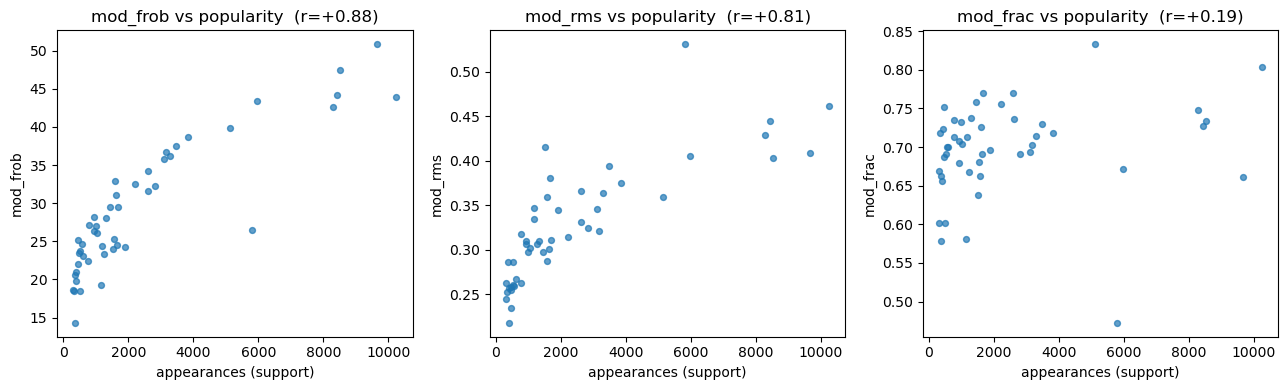

In [4]:
A  = np.array([r.n_items for r in elig])
AP = np.array([r.appearances for r in elig])
FR = np.array([r.mod_frac for r in elig])
RM = np.array([r.mod_rms for r in elig])
MF = np.array([r.mod_frob for r in elig])
corr = lambda x, y: float(np.corrcoef(x, y)[0, 1])
print("confound correlations (over support-gated species):")
print(f"  mod_frob :  vs appearances {corr(MF,AP):+.2f}   vs n_items {corr(MF,A):+.2f}")
print(f"  mod_rms  :  vs appearances {corr(RM,AP):+.2f}   vs n_items {corr(RM,A):+.2f}")
print(f"  mod_frac :  vs appearances {corr(FR,AP):+.2f}   vs n_items {corr(FR,A):+.2f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, (y, name) in zip(ax, [(MF, "mod_frob"), (RM, "mod_rms"), (FR, "mod_frac")]):
    a.scatter(AP, y, s=18, alpha=0.7)
    a.set_xlabel("appearances (support)"); a.set_ylabel(name)
    a.set_title(f"{name} vs popularity  (r={corr(AP,y):+.2f})")
fig.tight_layout()

## Interpretability: per-item drill-down

The feasibility question is whether the residual is *interpretable*. For a given species,
`item_modulation` ranks its items by role-shift magnitude and reports the partner species
each item pulls the team toward / away from, relative to the species' item-agnostic profile.
If the decomposition is meaningful, items should map to recognizable archetypes.

In [5]:
for species in ["Basculegion", "Wash Rotom", "Sneasler"]:
    print(f"\n=== {species}  (appearances ~{model.appearances(species):.0f}) ===")
    for d in potts.item_modulation(model, species)[:5]:
        toward = ", ".join(f"{s}(+{v:.2f})" for s, v in d.pulls_toward)
        away   = ", ".join(f"{s}({v:.2f})"  for s, v in d.pulls_away)
        print(f"  {str(d.item):15s} mag={d.magnitude:6.2f} | toward: {toward} | away: {away}")


=== Basculegion  (appearances ~8438) ===
  Choice Scarf    mag= 25.61 | toward: Drampa(+1.25), Machamp(+1.15), Frost Rotom(+1.10) | away: Garchomp(-4.53), Wash Rotom(-3.68), Hydreigon(-3.37)
  Focus Sash      mag= 19.11 | toward: Dragonite(+1.88), Pelipper(+1.73), Vivillon(+1.63) | away: Aerodactyl(-4.06), Glimmora(-3.97), Sneasler(-3.93)
  Mystic Water    mag= 14.87 | toward: Altaria(+1.81), Pelipper(+1.67), Armarouge(+1.60) | away: Palafin(-2.43), Starmie(-2.04), Primarina(-1.72)
  Sitrus Berry    mag= 13.72 | toward: Lycanroc Dusk(+2.53), Vanilluxe(+2.24), Talonflame(+1.70) | away: Garchomp(-3.33), Incineroar(-3.25), Wash Rotom(-3.19)
  White Herb      mag=  8.86 | toward: Conkeldurr(+2.04), Chandelure(+1.99), Sinistcha(+1.83) | away: Sneasler(-1.21), Kingambit(-0.84), Eternal Flower Floette(-0.84)

=== Wash Rotom  (appearances ~3475) ===
  Sitrus Berry    mag= 19.54 | toward: Aegislash(+1.83), Mimikyu(+1.44), Conkeldurr(+1.35) | away: Incineroar(-4.69), Sinistcha(-4.55), Farigiraf

Sanity read: **Choice Scarf** turns a species offensive and pushes it *away* from other
independent fast attackers (redundancy), while type-boost / defensive items pull toward the
matching archetype (rain enablers, defensive cores). The single-track item decomposition
recovers Pokemon-sensible role structure — the green light R2 was looking for.

## APC-corrected species interaction graph

Collapse each species-pair block to a scalar (Frobenius norm of its zero-sum form) and apply
the average-product correction to strip the popularity/degree background that `h` also
carries. `corrected = frob - apc`: positive is signal above background, negative is below.
`synergy` is the *signed* species-level coupling (positive = synergy, negative = redundancy /
anti-synergy).

In [6]:
g = potts.species_apc_graph(model)
iu = np.triu_indices(len(g.species), k=1)
pairs = sorted(zip(g.corrected[iu], iu[0], iu[1]), reverse=True)

print("Top APC-corrected species pairs (strongest interactions above background):")
for c, a, b in pairs[:12]:
    tag = "synergy" if g.synergy[a, b] > 0 else "redundant"
    print(f"  {g.species[a]:16s} -- {g.species[b]:16s}  corrected={c:5.2f}  "
          f"synergy={g.synergy[a, b]:+.3f}  ({tag})")

Top APC-corrected species pairs (strongest interactions above background):
  Archaludon       -- Pelipper          corrected= 6.63  synergy=+0.485  (synergy)
  Pelipper         -- Politoed          corrected= 6.34  synergy=-0.534  (redundant)
  Aerodactyl       -- Talonflame        corrected= 5.69  synergy=-0.295  (redundant)
  Alakazam         -- Meowstic          corrected= 5.54  synergy=+0.930  (synergy)
  Excadrill        -- Tyranitar         corrected= 5.10  synergy=+0.543  (synergy)
  Garchomp         -- Kommo-O           corrected= 4.21  synergy=-0.492  (redundant)
  Archaludon       -- Politoed          corrected= 4.18  synergy=+0.339  (synergy)
  Eternal Flower Floette -- Gardevoir         corrected= 3.97  synergy=-1.174  (redundant)
  Basculegion      -- Palafin           corrected= 3.95  synergy=-0.611  (redundant)
  Milotic          -- Wash Rotom        corrected= 3.86  synergy=-0.403  (redundant)
  Hawlucha         -- Snorlax           corrected= 3.81  synergy=+0.639  (syn

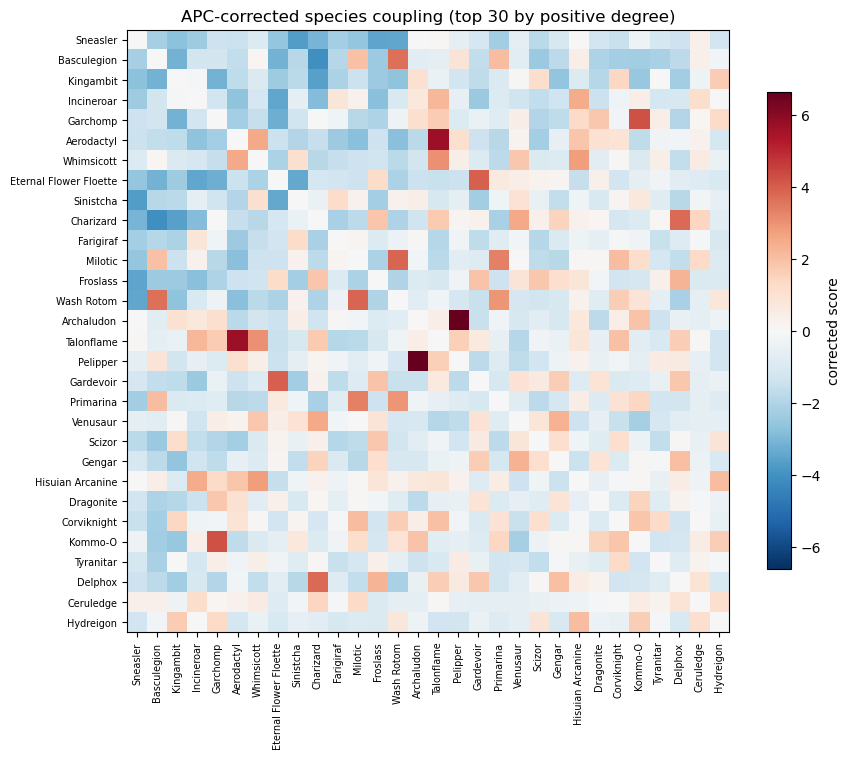

In [7]:
# Heatmap of the corrected graph over the most-connected species.
deg = g.corrected.clip(min=0).sum(axis=1)
top = np.argsort(-deg)[:30]
sub = g.corrected[np.ix_(top, top)]
fig, ax = plt.subplots(figsize=(9, 8))
vmax = np.abs(sub).max()
im = ax.imshow(sub, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(top))); ax.set_xticklabels([g.species[i] for i in top], rotation=90, fontsize=7)
ax.set_yticks(range(len(top))); ax.set_yticklabels([g.species[i] for i in top], fontsize=7)
ax.set_title("APC-corrected species coupling (top 30 by positive degree)")
fig.colorbar(im, ax=ax, shrink=0.7, label="corrected score")
fig.tight_layout()

## Verdict

- The encoding claim holds: the fitted flat `J` **is** a Potts coupling tensor; the block
  decomposition needs no change to fitting or sampling.
- The single-track item decomposition is **interpretable** (items map to archetypes), so it
  is load-bearing for the future species/item UI split, not decorative.
- The headline caveat is methodological: the raw modulation norm is a popularity proxy;
  report `mod_frob` / `mod_rms` / `mod_frac` together, always against support.

This is the zero-risk R2 spike. Next in the plan is R1 (the sampler rewrite that makes
species selection and item assignment separate moves).